# Temporal Primitive Feature Selection

Select a compact set of 8-12 temporal primitives for TIM/TIM v2 from the engineered temporal feature pool.

This notebook is analysis-only. It does not train SER models. It trains only lightweight feature-selection probes: L1 Logistic Regression, Random Forest, and permutation importance.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    sns = None
    SEABORN_AVAILABLE = False

try:
    display
except NameError:
    def display(value):
        print(value)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebook", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FE_DIR = PROJECT_ROOT / "results" / "feature_engineering"
OUT_DIR = PROJECT_ROOT / "results" / "feature_selection"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_DATASET = "IEMOCAP"
MI_THRESHOLD = 0.005
CORR_THRESHOLD = 0.90
TARGET_MIN_FEATURES = 8
TARGET_MAX_FEATURES = 12

print("PROJECT_ROOT =", PROJECT_ROOT)
print("FE_DIR       =", FE_DIR)
print("OUT_DIR      =", OUT_DIR)


PROJECT_ROOT = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo
FE_DIR       = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/results/feature_engineering
OUT_DIR      = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/results/feature_selection


## 2. Load Feature Tables


In [2]:
features_all = pd.read_csv(FE_DIR / "features_all.csv")
qualification = pd.read_csv(FE_DIR / "feature_qualification_table.csv")
emotion_assoc = pd.read_csv(FE_DIR / "emotion_association.csv")
distribution = pd.read_csv(FE_DIR / "feature_distribution_stats.csv")
importance_cache_path = FE_DIR / "temporal_probe_feature_importance.csv"
probe_importance = pd.read_csv(importance_cache_path) if importance_cache_path.exists() else pd.DataFrame()

metadata_cols = {
    "dataset", "dialogue_id", "utterance_id", "speaker_id", "turn_index",
    "label", "audio_path", "transcript_text", "start_time", "end_time",
}
feature_pool = [
    f for f in qualification["feature_name"].tolist()
    if f in features_all.columns and f not in metadata_cols
]

df = features_all[features_all["dataset"].eq(TARGET_DATASET)].copy()
if df.empty:
    raise ValueError(f"No rows found for TARGET_DATASET={TARGET_DATASET!r} in features_all.csv")

feature_pool = [f for f in feature_pool if f in df.columns]
df[feature_pool] = df[feature_pool].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=["label"]).reset_index(drop=True)

print("dataset rows:", len(df))
print("candidate features:", len(feature_pool))
print(df["label"].value_counts().to_string())


dataset rows: 7529
candidate features: 49
label
angry      2954
happy      1743
neutral    1708
sad        1124


/var/folders/62/f6sjw4bd0td2_b5c63kfyh0c0000gn/T/ipykernel_4881/2860856277.py:1: DtypeWarning: Columns (0: audio_path) have mixed types. Specify dtype option on import or set low_memory=False.
  features_all = pd.read_csv(FE_DIR / "features_all.csv")


## 3. Filter Near-Zero MI and Bad Distribution


In [3]:
y = df["label"].astype(str).values
y_encoded = LabelEncoder().fit_transform(y)
X_raw = df[feature_pool].replace([np.inf, -np.inf], np.nan)

mi_rows = []
for feature in feature_pool:
    x = X_raw[[feature]].copy()
    valid = x[feature].notna()
    if valid.sum() < 20 or x[feature].nunique(dropna=True) <= 1:
        mi = 0.0
    else:
        fill_value = float(x[feature].median()) if x[feature].notna().any() else 0.0
        xv = x[feature].fillna(fill_value).values.reshape(-1, 1)
        discrete = bool(set(pd.Series(xv.ravel()).dropna().unique()).issubset({0.0, 1.0}))
        mi = float(mutual_info_classif(xv, y_encoded, discrete_features=discrete, random_state=RANDOM_SEED)[0])
    mi_rows.append({"feature": feature, "mi_recomputed": mi})
mi_scores = pd.DataFrame(mi_rows)

score_table = qualification.rename(columns={"feature_name": "feature"}).merge(mi_scores, on="feature", how="right")
score_table = score_table.merge(
    distribution[distribution["dataset"].eq(TARGET_DATASET)][["feature", "missing_rate", "near_constant", "high_missing", "sparse_event", "zero_rate", "std"]],
    on="feature",
    how="left",
    suffixes=("", "_dist"),
)
if not probe_importance.empty:
    score_table = score_table.merge(
        probe_importance[probe_importance["dataset"].eq(TARGET_DATASET)][["feature", "permutation_importance_mean"]],
        on="feature",
        how="left",
    )
else:
    score_table["permutation_importance_mean"] = 0.0

score_table["mutual_information"] = score_table["mutual_information"].fillna(0.0)
score_table["effect_size"] = score_table["effect_size"].fillna(0.0)
score_table["complementarity_score"] = score_table["complementarity_score"].fillna(0.0)
score_table["permutation_importance_mean"] = score_table["permutation_importance_mean"].fillna(0.0)
score_table["missing_rate"] = score_table["missing_rate"].fillna(1.0)
score_table["near_constant"] = score_table["near_constant"].fillna(False).astype(bool)
score_table["high_missing"] = score_table["high_missing"].fillna(False).astype(bool)
primitive_preference = {
    "overlap_flag": 0.02,
    "overlap_frequency_window3": 0.02,
    "overlap_frequency_window5": 0.02,
    "strong_overlap": 0.02,
    "window5_gap_variance": 0.02,
    "speaker_switch": 0.01,
    "speaker_prev_overlap_rate": 0.02,
    "speaker_prev_interruption_rate": -0.03,
    "interruption_flag": -0.03,
    "interruption_frequency_window3": -0.03,
    "interruption_frequency_window5": -0.03,
    "competitive_overlap_proxy": -0.05,
    "cooperative_overlap_proxy": -0.05,
    "rhythm_variance_window5": -0.02,
    "consecutive_same_speaker_turns": -0.03,
    "turn_holding_duration_so_far": -0.02,
}
score_table["primitive_preference"] = score_table["feature"].map(primitive_preference).fillna(0.0)
score_table["selection_base_score"] = (
    score_table["mi_recomputed"]
    + score_table["mutual_information"]
    + 0.5 * score_table["effect_size"]
    + np.maximum(score_table["complementarity_score"], 0.0)
    + np.maximum(score_table["permutation_importance_mean"], 0.0)
    + score_table["primitive_preference"]
)

filtered = score_table[
    (score_table["mi_recomputed"] >= MI_THRESHOLD)
    & (~score_table["near_constant"])
    & (~score_table["high_missing"])
].copy()

removed_low_mi = score_table[~score_table["feature"].isin(filtered["feature"])].copy()
removed_low_mi.to_csv(OUT_DIR / "removed_low_mi_or_bad_distribution.csv", index=False)
filtered.to_csv(OUT_DIR / "candidate_after_mi_filter.csv", index=False)

print("features before filter:", len(score_table))
print("features after MI/distribution filter:", len(filtered))
display_cols = ["feature", "phenomenon_group", "mi_recomputed", "mutual_information", "effect_size", "missing_rate", "near_constant", "selection_base_score"]
display(filtered.sort_values("selection_base_score", ascending=False)[display_cols].head(20))


features before filter: 49
features after MI/distribution filter: 42


,feature,phenomenon_group,mi_recomputed,mutual_information,effect_size,missing_rate,near_constant,selection_base_score
32,silence_density_10s,Dialogue Rhythm,0.152303,0.152303,0.022274,0.00000,False,0.449071
10,previous_mean_gap,Response Dynamics,0.090331,0.089762,0.061529,0.06226,False,0.325727
12,window5_average_gap,Response Dynamics,0.059668,0.059668,0.044109,0.00000,False,0.256995
37,speaker_dominance_time_so_far,Speaker Behavior,0.041972,0.041972,0.018478,0.00000,False,0.223332
26,overlap_frequency_window5,Overlap / Interruption,0.064200,0.064200,0.088903,0.00000,False,0.199033
45,conflict_like_state,Dialogue State,0.028758,0.028758,0.245756,0.00000,False,0.184803
41,speaker_prev_mean_gap,Speaker Behavior,0.060937,0.060937,0.051256,0.00000,False,0.181616
21,overlap_flag,Overlap / Interruption,0.020104,0.020104,0.199533,0.00000,False,0.159974
44,rapid_exchange_state,Dialogue State,0.020446,0.020446,0.199970,0.00000,False,0.159460
1,gap_prev,Basic,0.063567,0.063567,0.040124,0.00000,False,0.155123


## 4. Remove Redundant Features with Spearman |rho| > 0.9


after redundancy prune: 30


,removed_feature,kept_feature,spearman_abs,removed_score,kept_score
0,interruption_frequency_window5,overlap_frequency_window5,1.000000,0.149033,0.199033
1,interruption_flag,overlap_flag,1.000000,0.109974,0.159974
2,speaker_prev_interruption_rate,speaker_prev_overlap_rate,1.000000,0.104439,0.154439
4,interruption_frequency_window3,overlap_frequency_window3,1.000000,0.098603,0.148603
8,rhythm_variance_window5,window5_gap_variance,1.000000,0.059055,0.099055
9,turn_holding_duration_so_far,speaker_prev_total_speaking_time,1.000000,0.052779,0.072779
10,competitive_overlap_proxy,strong_overlap,1.000000,0.023897,0.093897
3,same_speaker_continuation,speaker_switch,0.953926,0.101771,0.139839
11,consecutive_same_speaker_turns,speaker_switch,0.939157,0.000732,0.139839
7,consecutive_overlap_count,overlap_flag,0.915933,0.077299,0.159974


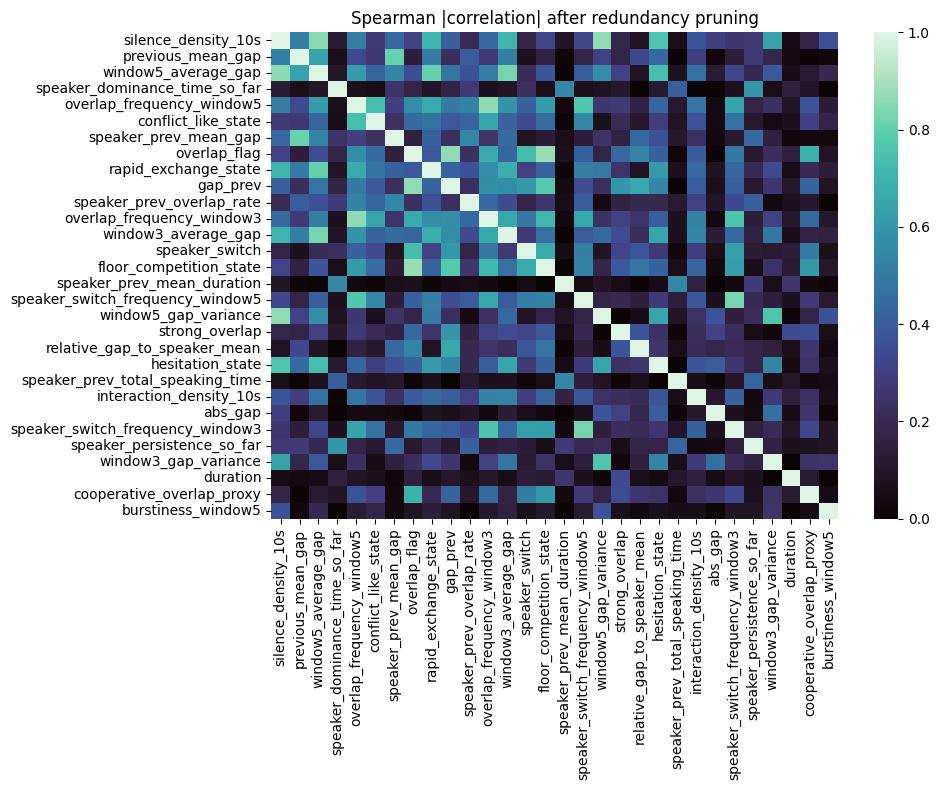

In [4]:
def redundancy_prune(features: list[str], scores: pd.DataFrame, corr_threshold: float = CORR_THRESHOLD):
    ranked = scores.set_index("feature").loc[features].sort_values("selection_base_score", ascending=False)
    corr = X_raw[features].fillna(X_raw[features].median(numeric_only=True)).corr(method="spearman").abs()
    selected = []
    removed = []
    for feature in ranked.index:
        redundant_with = None
        redundant_corr = None
        for kept in selected:
            rho = corr.loc[feature, kept]
            if pd.notna(rho) and rho > corr_threshold:
                redundant_with = kept
                redundant_corr = float(rho)
                break
        if redundant_with is None:
            selected.append(feature)
        else:
            removed.append({
                "removed_feature": feature,
                "kept_feature": redundant_with,
                "spearman_abs": redundant_corr,
                "removed_score": float(ranked.loc[feature, "selection_base_score"]),
                "kept_score": float(ranked.loc[redundant_with, "selection_base_score"]),
            })
    return selected, pd.DataFrame(removed), corr

redundancy_selected, redundancy_removed, corr_matrix = redundancy_prune(filtered["feature"].tolist(), filtered)
redundancy_removed.to_csv(OUT_DIR / "removed_high_correlation.csv", index=False)
corr_matrix.to_csv(OUT_DIR / "candidate_spearman_correlation.csv")

print("after redundancy prune:", len(redundancy_selected))
display(redundancy_removed.sort_values("spearman_abs", ascending=False).head(30))

plt.figure(figsize=(10, 8))
if SEABORN_AVAILABLE:
    sns.heatmap(corr_matrix.loc[redundancy_selected, redundancy_selected], cmap="mako", vmin=0, vmax=1)
else:
    plt.imshow(corr_matrix.loc[redundancy_selected, redundancy_selected], vmin=0, vmax=1)
    plt.colorbar()
plt.title("Spearman |correlation| after redundancy pruning")
plt.tight_layout()
plt.savefig(FIG_DIR / "spearman_after_pruning.png", dpi=180)
plt.show()


## 5. L1 Logistic Regression / Random Forest / Permutation Importance


In [5]:
model_features = redundancy_selected
X = X_raw[model_features].replace([np.inf, -np.inf], np.nan)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
)

l1_model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.5,
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ),
)
rf_model = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ),
)

models = {"l1_logistic": l1_model, "random_forest": rf_model}
metrics = []
importance_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics.append({
        "model": name,
        "WA": accuracy_score(y_test, pred),
        "UA": balanced_accuracy_score(y_test, pred),
        "Macro-F1": f1_score(y_test, pred, average="macro"),
        "WF1": f1_score(y_test, pred, average="weighted"),
        "num_input_features": len(model_features),
    })
    if name == "l1_logistic":
        clf = model.named_steps["logisticregression"]
        coef = np.abs(clf.coef_).mean(axis=0)
        for feature, value in zip(model_features, coef):
            importance_rows.append({"feature": feature, "source": "l1_abs_coef", "importance": float(value)})
    if name == "random_forest":
        clf = model.named_steps["randomforestclassifier"]
        for feature, value in zip(model_features, clf.feature_importances_):
            importance_rows.append({"feature": feature, "source": "rf_gini", "importance": float(value)})
    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=3,
        random_state=RANDOM_SEED,
        scoring="f1_macro",
        n_jobs=1,
    )
    for feature, mean, std in zip(model_features, perm.importances_mean, perm.importances_std):
        importance_rows.append({"feature": feature, "source": f"{name}_permutation", "importance": float(mean), "importance_std": float(std)})

probe_metrics = pd.DataFrame(metrics)
model_importance = pd.DataFrame(importance_rows)
probe_metrics.to_csv(OUT_DIR / "selection_probe_metrics.csv", index=False)
model_importance.to_csv(OUT_DIR / "model_feature_importance_long.csv", index=False)

display(probe_metrics)
display(model_importance.sort_values("importance", ascending=False).head(20))


TypeError: only integer scalar arrays can be converted to a scalar index

## 6. Aggregate Ranking and Select 8-12 Temporal Primitives


In [6]:
rank_sources = []
base = filtered[filtered["feature"].isin(model_features)][["feature", "selection_base_score", "mi_recomputed", "phenomenon_group"]].copy()
base["source"] = "statistical_base"
base["raw_score"] = base["selection_base_score"]
rank_sources.append(base[["feature", "source", "raw_score"]])

for source, frame in model_importance.groupby("source"):
    tmp = frame[["feature", "importance"]].copy().rename(columns={"importance": "raw_score"})
    tmp["source"] = source
    rank_sources.append(tmp[["feature", "source", "raw_score"]])

rank_long = pd.concat(rank_sources, ignore_index=True)
rank_long["raw_score"] = rank_long["raw_score"].fillna(0.0)
rank_long["rank"] = rank_long.groupby("source")["raw_score"].rank(ascending=False, method="average")
rank_long["norm_score"] = rank_long.groupby("source")["raw_score"].transform(
    lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
)

aggregate_rank = rank_long.groupby("feature").agg(
    aggregate_score=("norm_score", "mean"),
    mean_rank=("rank", "mean"),
    sources=("source", "nunique"),
).reset_index()
aggregate_rank = aggregate_rank.merge(
    filtered[["feature", "phenomenon_group", "mi_recomputed", "mutual_information", "effect_size", "complementarity_score", "selection_base_score"]],
    on="feature",
    how="left",
)
aggregate_rank = aggregate_rank.sort_values(["aggregate_score", "selection_base_score"], ascending=False)

selected_primitives = aggregate_rank.head(TARGET_MAX_FEATURES).copy()
if len(selected_primitives) < TARGET_MIN_FEATURES:
    warnings.warn(f"Only selected {len(selected_primitives)} features after filters; consider lowering MI_THRESHOLD.")

aggregate_rank.to_csv(OUT_DIR / "feature_ranking_all.csv", index=False)
selected_primitives.to_csv(OUT_DIR / "selected_temporal_primitives.csv", index=False)

payload = {
    "dataset": TARGET_DATASET,
    "mi_threshold": MI_THRESHOLD,
    "correlation_threshold": CORR_THRESHOLD,
    "target_min_features": TARGET_MIN_FEATURES,
    "target_max_features": TARGET_MAX_FEATURES,
    "selected_features": selected_primitives["feature"].tolist(),
    "feature_groups": selected_primitives.groupby("phenomenon_group")["feature"].apply(list).to_dict(),
}
(OUT_DIR / "selected_temporal_primitives.json").write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("Selected", len(selected_primitives), "features")
display(selected_primitives[["feature", "phenomenon_group", "aggregate_score", "mean_rank", "mi_recomputed", "mutual_information", "effect_size", "complementarity_score"]])


NameError: name 'model_importance' is not defined

## 7. Compact Temporal Encoder Design


In [7]:
selected_features = selected_primitives["feature"].tolist()
encoder_design = {
    "name": "TIMCompactTemporalEncoder",
    "input_features": selected_features,
    "input_dim": len(selected_features),
    "normalization": "fit mean/std on train split for continuous primitives; keep binary primitives as 0/1",
    "architecture": [
        {"layer": "Linear", "in": len(selected_features), "out": 32},
        {"layer": "LayerNorm", "dim": 32},
        {"layer": "GELU"},
        {"layer": "Dropout", "p": 0.2},
        {"layer": "Linear", "in": 32, "out": 64},
    ],
    "fusion": "concat temporal embedding with WavLM utterance embedding before TIM memory, or use as temporal branch residual in Dual-Branch TIM",
    "rationale": "features are low-redundancy temporal primitives selected by MI, Spearman pruning, L1, RF, and permutation importance",
}
(OUT_DIR / "temporal_encoder_design.json").write_text(json.dumps(encoder_design, ensure_ascii=False, indent=2), encoding="utf-8")

feature_list_md = "\n".join(f"- `{feature}`" for feature in selected_features)
report = f"""
# Temporal Primitive Feature Selection Report

## Summary

Selected **{len(selected_features)} temporal primitives** from {len(feature_pool)} engineered temporal features for compact TIM/TIM v2.

Selection rules:

- Remove features with recomputed Mutual Information `< {MI_THRESHOLD}` against emotion labels.
- Remove bad-distribution features: near-constant or high-missing.
- Greedily remove redundant features with Spearman `|rho| > {CORR_THRESHOLD}` using statistical score priority.
- Rank remaining features using L1 Logistic Regression, Random Forest, and permutation importance.

## Selected primitives

{feature_list_md}

## Probe metrics

{probe_metrics.to_markdown(index=False)}

## Temporal Encoder Design

Use a compact MLP temporal encoder:

```text
input_dim={len(selected_features)}
Linear({len(selected_features)}, 32)
LayerNorm(32)
GELU
Dropout(0.2)
Linear(32, 64)
```

The encoder should consume only the selected primitives above. Continuous primitives should be standardized using train-split statistics; binary primitives should remain 0/1. The resulting 64-dimensional temporal embedding can replace the current temporal encoder input in TIM, or become the temporal branch input in Dual-Branch TIM.

## Files

- `selected_temporal_primitives.csv`
- `selected_temporal_primitives.json`
- `feature_ranking_all.csv`
- `removed_high_correlation.csv`
- `removed_low_mi_or_bad_distribution.csv`
- `model_feature_importance_long.csv`
- `selection_probe_metrics.csv`
- `temporal_encoder_design.json`
"""
(OUT_DIR / "feature_selection_report.md").write_text(report.strip() + "\n", encoding="utf-8")
print(report)


NameError: name 'selected_primitives' is not defined

## 8. Save Summary


In [8]:
outputs = sorted(p.relative_to(OUT_DIR) for p in OUT_DIR.rglob("*") if p.is_file())
print(f"Saved {len(outputs)} files under {OUT_DIR}")
for path in outputs:
    print(path)


Saved 12 files under /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/results/feature_selection
candidate_after_mi_filter.csv
candidate_spearman_correlation.csv
feature_ranking_all.csv
feature_selection_report.md
figures/spearman_after_pruning.png
model_feature_importance_long.csv
removed_high_correlation.csv
removed_low_mi_or_bad_distribution.csv
selected_temporal_primitives.csv
selected_temporal_primitives.json
selection_probe_metrics.csv
temporal_encoder_design.json
